Name: **Stephane Chambrelain Talla Fotsing**  
Student Number: **ST139766**  
Program: **Data Analytics and Artificial Intelligence**  
Course - **Introduction to Artificial Intelligence**  
**Assignment 7: House Price Prediction Using Boston Housing Data**

## **Assignment Supervised machine Learning - Regression**

### **_House Price Prediction Using Bolton Housing Data_**
This dataset provides information about house prices in Bolton. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "Boston Housing Dataset" from sklearn. The regression model will either be a Decision Tree or Random Forest regressor.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (Bolton Housing):

* CRIM: Crime rate by town
* ZN: Proportion of residential land zoned for large lots
* INDUS: Proportion of non-retail business acres per town
* CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX: Nitric oxide concentration (parts per 10 million)
* RM: Average number of rooms per dwelling
* AGE: Proportion of owner-occupied units built before 1940
* DIS: Weighted distances to five Boston employment centers
* RAD: Index of accessibility to radial highways
* TAX: Full-value property tax rate per `$10,000`
* PTRATIO: Pupil-teacher ratio by town
* B: Proportion of Black population
* LSTAT: Percentage of lower status of the population
* MEDV (Target): Median value of owner-occupied homes in `$1,000s`



**Dataset is from sklearn Datasets**

In [1]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:
# Data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

In [2]:
# --- Data Collection and Loading ---
# TODO: Load the 'Boston Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `load_boston()` from `sklearn.datasets`
# Load dataset and convert to DataFrame:
# Add your code here:
# Load the Boston Housing dataset
housing = fetch_openml(name="boston", version=1, as_frame=True)
# Combine features and target into a DataFrame
df = housing.data.copy()
df["MEDV"] = pd.to_numeric(housing.target)

In [3]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.
# Add your code here:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.
# Add your code here:
# Check column names, data types, and non-null counts
df.info()
print("-" * 38)
# View summary statistics for all columns
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB
--------------------------------------


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506,506.000000,506.000000,506.000000,506.000000,506,506.000000,506.000000,506.000000,506.000000,506.000000
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,24,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,471,NaN,NaN,NaN,NaN,132,NaN,NaN,NaN,NaN,NaN
mean,3.613524,11.363636,11.136779,NaN,0.554695,6.284634,68.574901,3.795043,NaN,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,NaN,0.115878,0.702617,28.148861,2.105710,NaN,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,NaN,0.385000,3.561000,2.900000,1.129600,NaN,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,NaN,0.449000,5.885500,45.025000,2.100175,NaN,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,NaN,0.538000,6.208500,77.500000,3.207450,NaN,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,NaN,0.624000,6.623500,94.075000,5.188425,NaN,666.000000,20.200000,396.225000,16.955000,25.000000


In [5]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.
# Add your code here:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


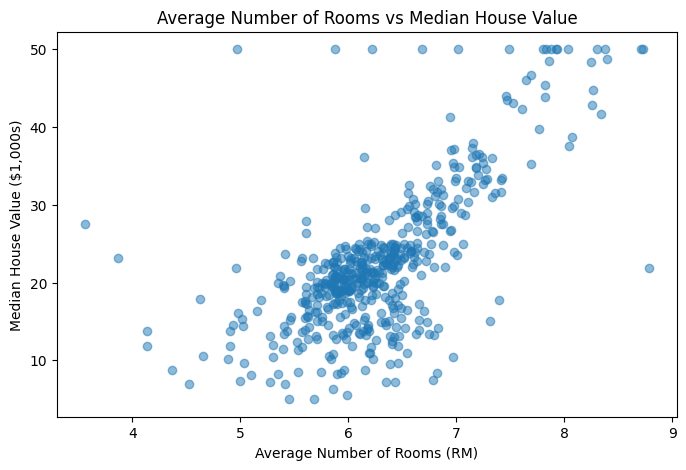

In [6]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable.
# Example: Use `plt.scatter()` to visualize the relationship between features like 'RM' (average number of rooms) and the target ('MEDV').
# Add your code here:
# Plot average number of rooms against median house value
plt.figure(figsize=(8, 5))
plt.scatter(df["RM"], df["MEDV"], alpha=0.5)
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value ($1,000s)")
plt.title("Average Number of Rooms vs Median House Value")
plt.show()

In [8]:
# TODO: Create a function to automate scatter plots for all features vs the target variable.
# Hint: The function should loop over a list of features and plot scatter plots for each.
# Define your function here:
def plot_scatter(data, features, target="MEDV"):
    rows = (len(features) + 2) // 3
    plt.figure(figsize=(15, rows * 4))
    for i, feature in enumerate(features, start=1):
        plt.subplot(rows, 3, i)
        plt.scatter(data[feature], data[target], alpha=0.5)
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f"{feature} vs {target}")
    plt.tight_layout()
    plt.show()

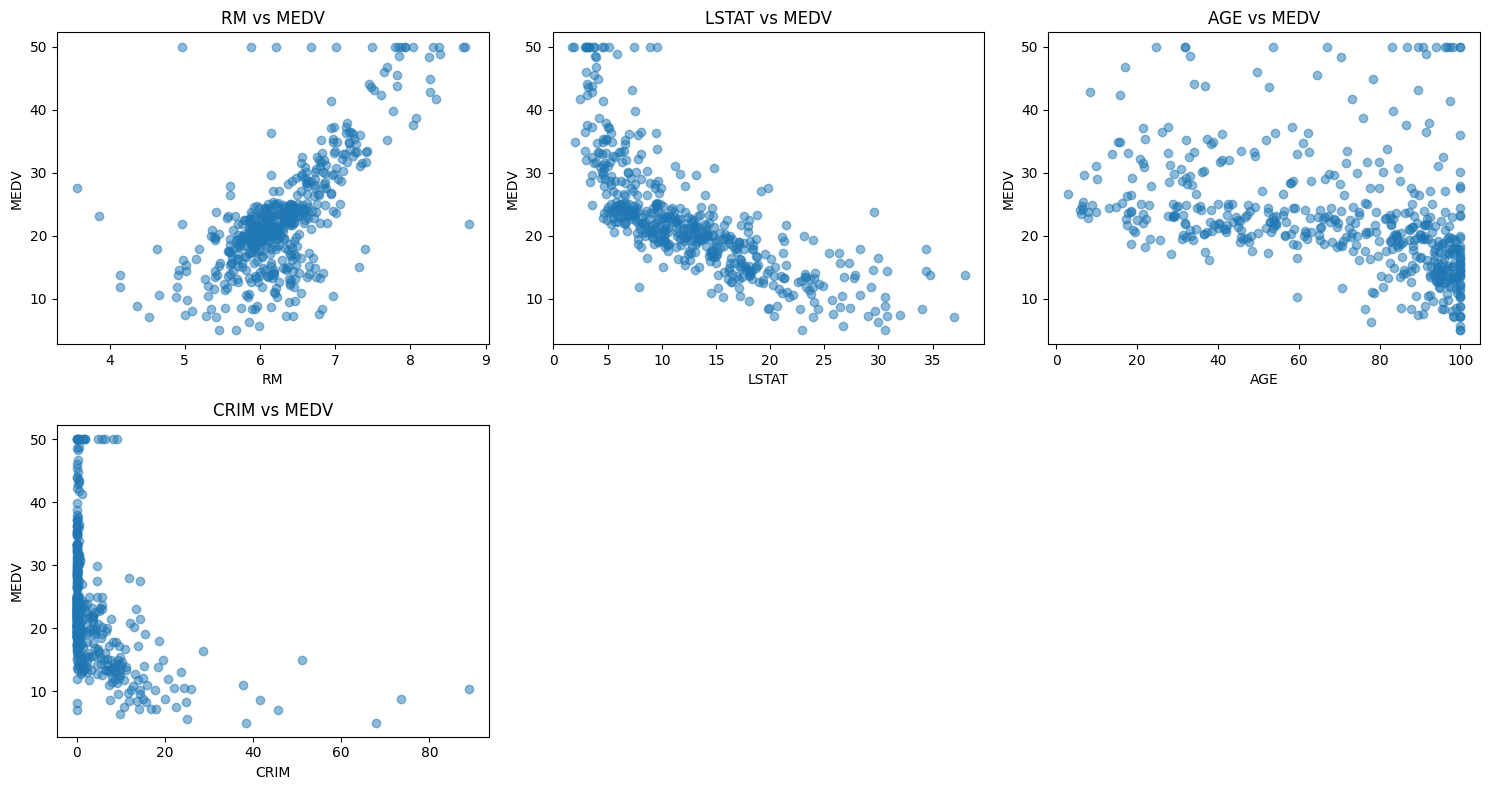

In [9]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Example: ['RM', 'LSTAT', 'AGE', 'CRIM']
# Target: 'MEDV'
# Add your code here:
features = ["RM", "LSTAT", "AGE", "CRIM"]
plot_scatter(df, features, target="MEDV")

In [10]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.
# Define X (features) and y (target) and perform the train-test split:
# Define features and target
X = df.drop(columns="MEDV")
y = df["MEDV"]
# Split: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# TODO: Choose an appropriate regression model: Decision Tree or Random Forest.
# Hint: Use either `DecisionTreeRegressor` or `RandomForestRegressor` from `sklearn.tree` or `sklearn.ensemble`.
# Define your regression model here:
# Initialize the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [12]:
# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.
# Add your code here:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [13]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.
# Perform parameter tuning on the model if needed to improve the performance of your model.
# Add your parameter tuning code here:
# Predict on the test set and calculate the evaluation metrics:
# Define parameter values to compare
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4]
}
# Tune using cross-validation on the training data only
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
# Select the best model
model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)
# Predict on the test set
y_pred = model.predict(X_test)
# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 100}
RMSE: 3.0178
R-squared: 0.8758


In [14]:
# --- Model Prediction ---
# TODO: Predict house prices from a new set of feature inputs.
# Example new data: Use hypothetical or randomly generated values for the features.
# Example new data: CRIM = 0.2, ZN = 12.5, INDUS = 7.07, CHAS = 0, NOX = 0.5, RM = 6.5, AGE = 68, DIS = 4.0, RAD = 2, TAX = 250, PTRATIO = 17, B = 400, LSTAT = 12
# Add your prediction code here:
# Create new data with the same column order as the training features
new_data = pd.DataFrame({"CRIM": [0.2], "ZN": [12.5], "INDUS": [7.07], "CHAS": [0],
                         "NOX": [0.5], "RM": [6.5], "AGE": [68], "DIS": [4.0],
                         "RAD": [2], "TAX": [250], "PTRATIO": [17],"B": [400], "LSTAT": [12]
                        }, columns=X.columns)
# Predict the house value
prediction = model.predict(new_data)

print(f"Predicted House Value: ${prediction[0] * 1000:,.2f}")

Predicted House Value: $22,327.84


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
!ls -la "/content/drive/MyDrive"

total 545
drwx------ 5 root root   4096 Sep 13 20:10  .
drwx------ 5 root root   4096 Sep 13 20:10  ..
-rw------- 1 root root    175 Nov 27  2021 'Altyd gefokus - Midterm Exam-Online.gdoc'
-rw------- 1 root root     48 Jan 17  2020  BackupRestoreTest.txt
drwx------ 2 root root   4096 May  3  2021  Classroom
-rw------- 1 root root    175 Oct  3  2024 'Client Intake Form - Fillable - 2024.gdoc'
-rw------- 1 root root 531006 Sep 30  2024 'Client Intake Form - Fillable - 2024.pdf'
drwx------ 2 root root   4096 May  1 12:32 'Colab Notebooks'
-rw------- 1 root root   3815 May 26 15:49  employees.csv
drwx------ 2 root root   4096 Feb 26  2021  Takeout


In [17]:
!find "/content/drive/MyDrive/Colab Notebooks" -iname "*Lesson*7*.ipynb"

/content/drive/MyDrive/Colab Notebooks/Lesson_7_assignment.ipynb


In [18]:
!git clone https://github.com/StephaneTF/colab-git-assignment2-ST.git /content/colab-git-assignment2-ST

Cloning into '/content/colab-git-assignment2-ST'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 57 (delta 22), reused 19 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 942.51 KiB | 5.96 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [19]:
!ls -la /content/colab-git-assignment2-ST

total 668
drwxr-xr-x 6 root root   4096 Sep 13 20:15  .
drwxr-xr-x 1 root root   4096 Sep 13 20:15  ..
-rw-r--r-- 1 root root   5415 Sep 13 20:15  assignment2.ipynb
drwxr-xr-x 2 root root   4096 Sep 13 20:15  Assignment_8
drwxr-xr-x 2 root root   4096 Sep 13 20:15  Assignment_9
drwxr-xr-x 8 root root   4096 Sep 13 20:15  .git
drwxr-xr-x 2 root root   4096 Sep 13 20:15  Lesson_10_assignment
-rw-r--r-- 1 root root  12704 Sep 13 20:15  Lesson_3_assignment.ipynb
-rw-r--r-- 1 root root  80271 Sep 13 20:15 'Lesson 4 assignment.ipynb'
-rw-r--r-- 1 root root 549515 Sep 13 20:15  Lesson_5_Assignment.ipynb
